In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install evaluate
!pip install rouge_score
!pip install bert_score
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [2]:
from unsloth import FastLanguageModel
from transformers import AutoTokenizer, GenerationConfig
from datasets import load_dataset
from trl import SFTConfig, SFTTrainer
import numpy as np
import evaluate
import random
import torch
import time

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [3]:
torch.cuda.is_available()

True

In [4]:
# ===== seed =====
SEED = 42
def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# -------- data config --------
DATASET_NAME = "databricks/databricks-dolly-15k"
PERCENT = 0.15  # 5% percentage of dataset taken.
TRAIN_FRAC = 0.8
DEV_FRAC   = 0.133

# -------- model config --------
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
LEARNING_RATE = 2e-4
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05

# -------- train config --------
EPOCHS = 1
BATCH_SIZE = 32
MAX_LENGTH = 128
WEIGHT_DECAY = 0.0
LOGGING_STEPS = 50

In [5]:
# 1. Cargar el dataset
dataset = load_dataset(DATASET_NAME, split="train")

def clean_text(text):
    text = text.replace("”", '"').replace("“", '"').replace("’", "'")
    return text

dataset = dataset.map(lambda x: {
    "instruction": clean_text(x["instruction"]),
    "context": clean_text(x["context"]),
    "response": clean_text(x["response"]),
    "category": clean_text(x["category"])
})

dataset = dataset.class_encode_column("category")

# 2. Downsample equilibrado: Dolly tiene varias categorías (closed_qa, summarization, etc.)
# Seleccionamos una fracción manteniendo la diversidad de tareas
ds_dict = dataset.train_test_split(train_size=PERCENT, seed=SEED, stratify_by_column="category")
subset_10 = ds_dict["train"]

# 1. Separar el Test Set (siguiendo el requisito de ~1k, pero ajustado al 10% total sería menos)
# Si quieres mantener el ratio 12/2/1 sobre las 1,500 muestras:
temp_split = subset_10.train_test_split(test_size=(1-TRAIN_FRAC-DEV_FRAC), seed=SEED)
test_ds = temp_split["test"] # ~100 muestras

# 2. Separar Train y Dev del resto
train_dev_split = temp_split["train"].train_test_split(test_size=DEV_FRAC, seed=SEED)
train_ds = train_dev_split["train"]
dev_ds = train_dev_split["test"]

print(f"Subsets finales: Train: {len(train_ds)} | Dev: {len(dev_ds)} | Test: {len(test_ds)}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token_id = tokenizer.eos_token_id


README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

Map:   0%|          | 0/15011 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/15011 [00:00<?, ? examples/s]

Subsets finales: Train: 1820 | Dev: 280 | Test: 151


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

In [6]:
def tokenize_function(example):

    text = f"Instruction:\n{example['instruction']}\n\nResponse:\n{example['response']}"

    tokenized = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length"
    )

    # Para CausalLM, las etiquetas suelen ser una copia de los input_ids
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

# Aplicar tokenización eliminando TODAS las columnas originales
column_names = dataset.column_names # ["instruction", "context", "response", "category"]

train_ds_tokenized = train_ds.map(
    tokenize_function,
    remove_columns=column_names,
    batched=False
)

dev_ds_tokenized = dev_ds.map(
    tokenize_function,
    remove_columns=column_names,
    batched=False
)

Map:   0%|          | 0/1820 [00:00<?, ? examples/s]

Map:   0%|          | 0/280 [00:00<?, ? examples/s]

In [7]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = MODEL_NAME, # "unsloth/tinyllama-bnb-4bit" ESTO ESTABA ANTES
    max_seq_length = MAX_LENGTH,
    dtype = None,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r = LORA_R,
    target_modules = ["q_proj", "v_proj"],
    lora_alpha = LORA_ALPHA,
    lora_dropout = LORA_DROPOUT,
    bias = "none",
    use_gradient_checkpointing = False,
    random_state = SEED,
)

args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        num_train_epochs = EPOCHS,
        learning_rate = LEARNING_RATE,
        logging_steps = LOGGING_STEPS,
        optim = "adamw_8bit",
        weight_decay = WEIGHT_DECAY,
        lr_scheduler_type = "linear",
        seed = SEED,
        output_dir = "outputs",
    )

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_ds_tokenized,
    dataset_text_field = "text",
    max_seq_length = MAX_LENGTH,
    packing = True,
    args = args
)

==((====))==  Unsloth 2025.12.9: Fast Llama patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/762M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2025.12.9 patched 22 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [8]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats() # Reinicia el contador de memoria pico

trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,820 | Num Epochs = 1 | Total steps = 228
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 2,252,800 of 1,102,301,184 (0.20% trained)


Step,Training Loss
50,2.394400
100,1.279500
150,1.250600
200,1.265100


In [9]:
# Memoria
allocated_memory = torch.cuda.memory_allocated() / (1024 ** 3) # Memoria que realmente contienen pesos, gradientes y activaciones
peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 3) # Convertir bytes a GB
print(f"\nMemoria Activa: {allocated_memory:.2f} GB")
print(f"Consumo máximo de VRAM: {peak_memory:.2f} GB")

# Tiempo
training_time = trainer_stats.metrics['train_runtime']
print(f"\nTiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Muestras por segundo: {trainer_stats.metrics['train_samples_per_second']:.2f}")


Memoria Activa: 0.74 GB
Consumo máximo de VRAM: 0.81 GB

Tiempo total de entrenamiento: 311.61 segundos
Muestras por segundo: 5.84


## Evaluación

### Métricas

In [10]:
# Cargar métricas
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")

# Ajustes del tokenizer
tokenizer.padding_side = "left"
tokenizer.pad_token = tokenizer.eos_token

gen_cfg = GenerationConfig(
    max_new_tokens=MAX_LENGTH,
    do_sample=False,
    pad_token_id=tokenizer.eos_token_id
)

def generate(model, ds, batch_size=8):
    model.eval()
    preds = []
    start = time.time()
    total_tokens = 0

    for i in range(0, len(ds), batch_size):
        batch = ds[i:i+batch_size]
        prompts = [f"Instruction:\n{x}\n\nResponse:\n" for x in batch["instruction"]]

        inputs = tokenizer(prompts, return_tensors="pt", padding=True).to(model.device)
        input_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            out = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                generation_config=gen_cfg
            )

        gen_tokens = out[:, input_len:]
        total_tokens += gen_tokens.numel()
        decoded_preds = tokenizer.batch_decode(gen_tokens, skip_special_tokens=True)
        preds += [p.strip() for p in decoded_preds]

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    duration = time.time() - start
    throughput = total_tokens / duration
    return preds, throughput

refs = test_ds["response"]

# 1️⃣ Evaluar modelo con LoRA activado
print("Evaluando modelo con LoRA...")
lora_preds, lora_tp = generate(model, test_ds)

# 2️⃣ Evaluar modelo base "puro" (desactivando LoRA)
with model.disable_adapter():
    print("Evaluando modelo base (LoRA desactivado)...")
    orig_preds, orig_tp = generate(model, test_ds)

# 3️⃣ Cálculo de métricas
def compute_metrics(predictions, references, name="Modelo"):
    print(f"\n--- Resultados: {name} ---")

    results_rouge = rouge.compute(predictions=predictions, references=references)
    print(f"ROUGE: {results_rouge}")

    results_bleu = bleu.compute(predictions=predictions, references=[[r] for r in references])
    print(f"BLEU: {results_bleu['bleu']:.4f}")

    results_bert = bertscore.compute(
        predictions=predictions,
        references=references,
        lang="en",
        model_type="bert-base-uncased",
        device="cuda" if torch.cuda.is_available() else "cpu"
    )
    mean_f1 = np.mean(results_bert["f1"])
    print(f"BERTScore F1 (Mean): {mean_f1:.4f}")

    return {"rouge": results_rouge, "bleu": results_bleu, "bert": mean_f1}

metrics_orig = compute_metrics(orig_preds, refs, "Base Model")
metrics_lora = compute_metrics(lora_preds, refs, "LoRA Model")

print(f"\nThroughput Base: {orig_tp:.2f} tokens/s")
print(f"Throughput LoRA: {lora_tp:.2f} tokens/s")


Evaluando modelo con LoRA...
Evaluando modelo base (LoRA desactivado)...

--- Resultados: Base Model ---
ROUGE: {'rouge1': np.float64(0.2110854680171469), 'rouge2': np.float64(0.06718285578112307), 'rougeL': np.float64(0.1664499343191535), 'rougeLsum': np.float64(0.17147548599047352)}
BLEU: 0.0424


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BERTScore F1 (Mean): 0.5004

--- Resultados: LoRA Model ---
ROUGE: {'rouge1': np.float64(0.16902259822735294), 'rouge2': np.float64(0.07173011024953593), 'rougeL': np.float64(0.14405192089133023), 'rougeLsum': np.float64(0.14794018756969202)}
BLEU: 0.0238
BERTScore F1 (Mean): 0.4088

Throughput Base: 173.93 tokens/s
Throughput LoRA: 159.12 tokens/s


### Evaluación humana

In [11]:
gen_cfg = GenerationConfig(
    max_new_tokens=100,
    do_sample=False,
    num_beams=1,
    pad_token_id=tokenizer.eos_token_id,
)

nums = random.sample(range(len(test_ds)), k=5)
dash_line = "-" * 100

# Aseguramos modo evaluación
model.eval()

for idx, i in enumerate(nums):
    instruction = test_ds[i]["instruction"]
    reference = test_ds[i]["response"]

    prompt = f"Instruction: {instruction}\nResponse:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        # Modelo base "puro"
        with model.disable_adapter():  # desactiva LoRA
            out_base = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                generation_config=gen_cfg
            )
            text_base = tokenizer.decode(out_base[0], skip_special_tokens=True)

        # Modelo con LoRA
        out_lora = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            generation_config=gen_cfg
        )
        text_lora = tokenizer.decode(out_lora[0], skip_special_tokens=True)

    print(dash_line)
    print(f"MUESTRA {idx}:")
    print(f"\nPROMPT:\n{prompt}")
    print(f"\nBASELINE HUMAN RESPONSE:\n{reference}")
    print(f"\nBASE MODEL:\n{text_base}")
    print(f"\nLoRA MODEL:\n{text_lora}")

----------------------------------------------------------------------------------------------------
MUESTRA 0:

PROMPT:
Instruction: What can be done to resolve issues with climate change
Response:

BASELINE HUMAN RESPONSE:
Climate change is dangerous as it alters the climate very rapidly leading to shift in seasons and damaging the habitats of wild life for example. Some ways to control it could be: 
1. Reduce air pollution - move towards electric vehicles. Also move towards renewable source of energy so that increased demand can be met.
2. Control ozone depletion - Ban use of chemicals that encourage ozone hole depletion as this leads to melting of polar ice caps.
3. Plant more trees - They help in regulating the environment.

BASE MODEL:
Instruction: What can be done to resolve issues with climate change
Response: The United Nations Framework Convention on Climate Change (UNFCCC) has established a number of mechanisms to address climate change, including the following:
1. The Paris

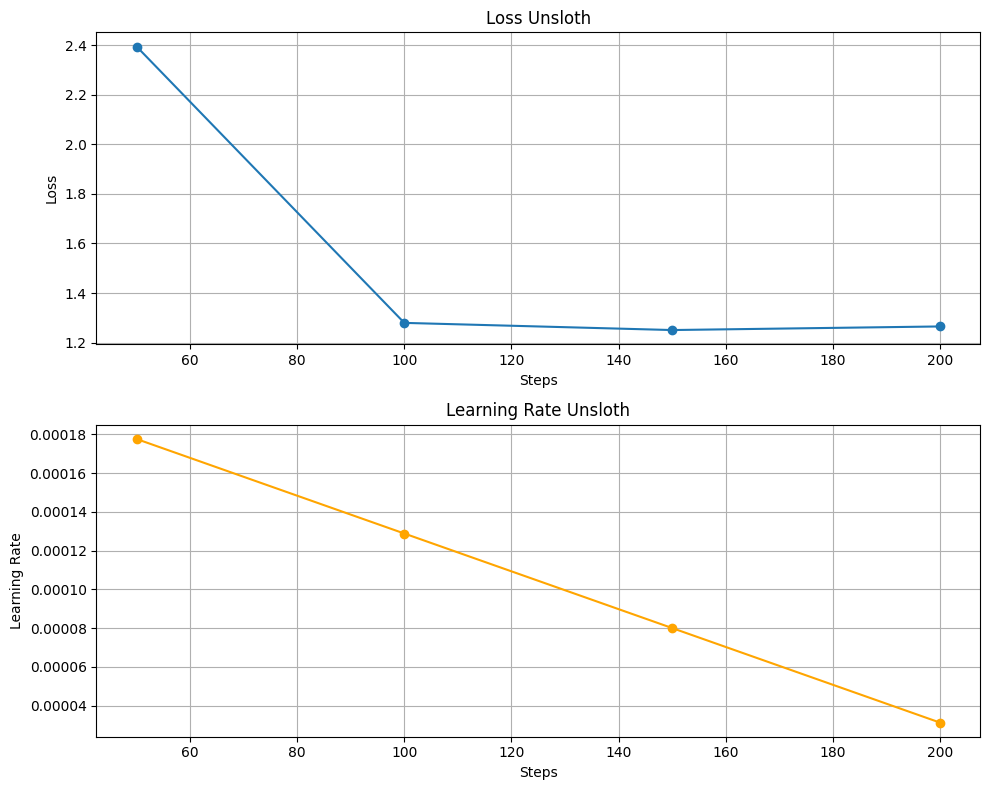

In [12]:
import matplotlib.pyplot as plt

# Extraer datos
losses = [x["loss"] for x in trainer.state.log_history if "loss" in x]
lrs = [x["learning_rate"] for x in trainer.state.log_history if "learning_rate" in x]
steps_loss = [x["step"] for x in trainer.state.log_history if "loss" in x]
steps_lr = [x["step"] for x in trainer.state.log_history if "learning_rate" in x]

# Crear figura con 2 subplots
fig, axs = plt.subplots(2, 1, figsize=(10,8))

# Loss
axs[0].plot(steps_loss, losses, marker='o', linestyle='-')
axs[0].set_xlabel("Steps")
axs[0].set_ylabel("Loss")
axs[0].set_title("Loss Unsloth")
axs[0].grid(True)

# Learning Rate
axs[1].plot(steps_lr, lrs, marker='o', linestyle='-', color='orange')
axs[1].set_xlabel("Steps")
axs[1].set_ylabel("Learning Rate")
axs[1].set_title("Learning Rate Unsloth")
axs[1].grid(True)

plt.tight_layout()
plt.show()